# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS


from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

# Data Load

In [2]:
df = pd.read_csv("train.csv")

# EDA

In [3]:
print(df.shape)

(120000, 3)


In [4]:
df.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [5]:
df.columns

Index(['Class Index', 'Title', 'Description'], dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Class Index  120000 non-null  int64 
 1   Title        120000 non-null  object
 2   Description  120000 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.7+ MB


In [7]:
df.describe()

,Class Index
count,120000.000000
mean,2.500000
std,1.118039
min,1.000000
25%,1.750000
50%,2.500000
75%,3.250000
max,4.000000


In [8]:
df.isnull().sum()

Class Index    0
Title          0
Description    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["text"] = df["Title"] + " " + df["Description"]

In [11]:
df.head(2)

,Class Index,Title,Description,text
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",Wall St. Bears Claw Back Into the Black (Reute...
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Carlyle Looks Toward Commercial Aerospace (Reu...


In [12]:
df = df[["Class Index","text"]]

In [13]:
df.head(2)

,Class Index,text
0,3,Wall St. Bears Claw Back Into the Black (Reute...
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...


In [14]:
df.shape

(120000, 2)

In [15]:
df["Class Index"].value_counts()

Class Index
3    30000
4    30000
2    30000
1    30000
Name: count, dtype: int64

In [16]:
df["Class Index"].value_counts(normalize=True)

Class Index
3    0.25
4    0.25
2    0.25
1    0.25
Name: proportion, dtype: float64

<Axes: xlabel='Class Index', ylabel='count'>

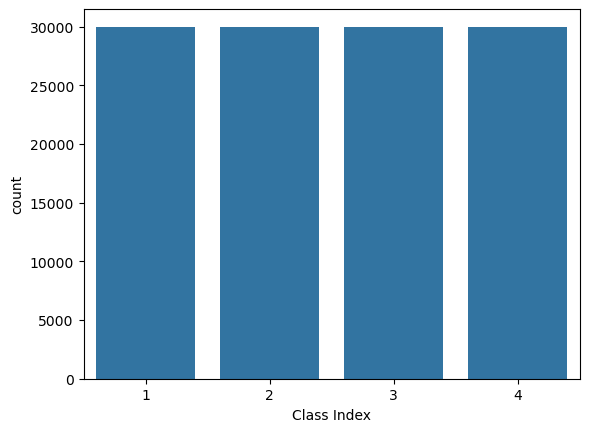

In [17]:
sns.countplot(x=df["Class Index"])

In [18]:
df["text_length"] = df["text"].str.len()

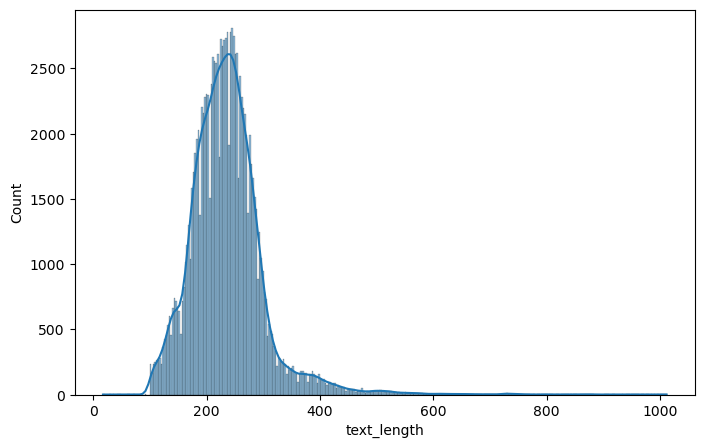

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df["text_length"],kde=True)
plt.show()

<Axes: xlabel='text_length'>

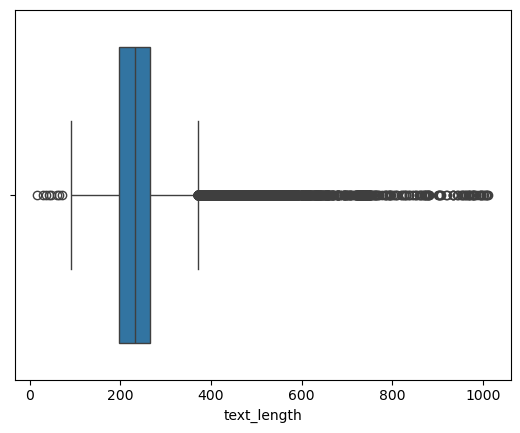

In [20]:
sns.boxplot(x=df["text_length"])

# X and Y split

In [21]:
X = df["text"]

In [22]:
y = df["Class Index"]

# train_test_split

In [23]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

# Preprocessing

In [24]:
def preprocess(text):
    text = text.lower()
    text = re.sub("[^a-zA-Z0-9 ]","",text)
    text = text.split()
    text = [word for word in text if word not in ENGLISH_STOP_WORDS]
    text = " ".join(text)
    return text

In [25]:
X_train_preprocess = X_train.apply(preprocess)
X_test_preprocess = X_test.apply(preprocess)                           

In [26]:
tfidf = TfidfVectorizer(ngram_range=(1, 2),
    max_df=0.95,
    min_df=2,
    max_features=10000)
X_train_vec = tfidf.fit_transform(X_train_preprocess)
X_test_vec = tfidf.transform(X_test_preprocess)


# Model Building and Evaluation

# Logistic Regression

In [27]:
lr = LogisticRegression(C=2,max_iter=2000,random_state=42)

lr.fit(X_train_vec,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,2
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [28]:
lr_pred = lr.predict(X_test_vec)

In [29]:
lr_pred

array([3, 3, 2, ..., 2, 1, 2], shape=(24000,))

In [30]:
confusion_matrix(y_test,lr_pred)

array([[5352,  193,  246,  165],
       [  60, 5921,   45,   32],
       [ 181,   40, 5233,  457],
       [ 208,   56,  434, 5377]])

In [31]:
print(classification_report(y_test,lr_pred))

              precision    recall  f1-score   support

           1       0.92      0.90      0.91      5956
           2       0.95      0.98      0.97      6058
           3       0.88      0.89      0.88      5911
           4       0.89      0.89      0.89      6075

    accuracy                           0.91     24000
   macro avg       0.91      0.91      0.91     24000
weighted avg       0.91      0.91      0.91     24000



# Naive Bayes

In [32]:
nb =  MultinomialNB()
nb.fit(X_train_vec,y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [33]:
nb_pred = nb.predict(X_test_vec)

In [34]:
nb_pred 

array([3, 3, 2, ..., 2, 1, 2], shape=(24000,))

In [35]:
confusion_matrix(y_test,nb_pred)

array([[5307,  234,  275,  140],
       [  68, 5932,   27,   31],
       [ 210,   60, 5080,  561],
       [ 238,   69,  455, 5313]])

In [36]:
print(classification_report(y_test,nb_pred))

              precision    recall  f1-score   support

           1       0.91      0.89      0.90      5956
           2       0.94      0.98      0.96      6058
           3       0.87      0.86      0.86      5911
           4       0.88      0.87      0.88      6075

    accuracy                           0.90     24000
   macro avg       0.90      0.90      0.90     24000
weighted avg       0.90      0.90      0.90     24000



# SVM

In [37]:
svm = LinearSVC(C=2,max_iter=10000,random_state=42)

svm.fit(X_train_vec,y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,2
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,42


In [38]:
svm_pred = svm.predict(X_test_vec)

In [39]:
svm_pred

array([3, 3, 2, ..., 2, 1, 2], shape=(24000,))

In [40]:
confusion_matrix(y_test,svm_pred)

array([[5327,  188,  264,  177],
       [  68, 5905,   49,   36],
       [ 204,   58, 5189,  460],
       [ 214,   57,  460, 5344]])

In [41]:
print(classification_report(y_test,svm_pred))

              precision    recall  f1-score   support

           1       0.92      0.89      0.91      5956
           2       0.95      0.97      0.96      6058
           3       0.87      0.88      0.87      5911
           4       0.89      0.88      0.88      6075

    accuracy                           0.91     24000
   macro avg       0.91      0.91      0.91     24000
weighted avg       0.91      0.91      0.91     24000



In [42]:
lr_acc = lr.score(X_test_vec, y_test)
nb_acc = nb.score(X_test_vec, y_test)
svm_acc = svm.score(X_test_vec, y_test)

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes", "Linear SVM"],
    "Accuracy": [lr_acc, nb_acc, svm_acc]
})

comparison = comparison.sort_values(by="Accuracy", ascending=False)

print(comparison)

                 Model  Accuracy
0  Logistic Regression  0.911792
2           Linear SVM  0.906875
1          Naive Bayes  0.901333


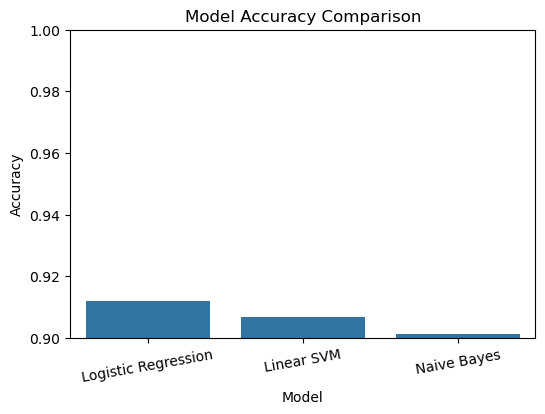

In [43]:
plt.figure(figsize=(6,4))
sns.barplot(data=comparison, x="Model", y="Accuracy")
plt.ylim(0.90, 1.00)
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=10)
plt.show()

# Final Model Pipeline  ( Model = Logistic Regression)

In [44]:
def preprocess_texts(x):
    return [preprocess(text) for text in x]

In [45]:
model = Pipeline([
    ("preprocessing",FunctionTransformer(preprocess_texts,validate=False)),
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2),
    max_df=0.95,
    min_df=2,
    max_features=10000)),
     ("lr",LogisticRegression(C=2,max_iter=2000,random_state=42))
])
     

In [46]:
model.fit(X_train,y_train)

,steps,"[('preprocessing', ...), ('tfidf', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,func,<function pre...001FDEA4D3920>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None


In [47]:
y_pred = model.predict(X_test)

In [48]:
y_pred

array([3, 3, 2, ..., 2, 1, 2], shape=(24000,))

In [49]:
model.score(X_test,y_test)

0.9117916666666667

In [50]:
confusion_matrix(y_test,y_pred)

array([[5352,  193,  246,  165],
       [  60, 5921,   45,   32],
       [ 181,   40, 5233,  457],
       [ 208,   56,  434, 5377]])

In [51]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           1       0.92      0.90      0.91      5956
           2       0.95      0.98      0.97      6058
           3       0.88      0.89      0.88      5911
           4       0.89      0.89      0.89      6075

    accuracy                           0.91     24000
   macro avg       0.91      0.91      0.91     24000
weighted avg       0.91      0.91      0.91     24000



In [52]:
model.predict(["Apple has unveiled its latest AI-powered iPhone with improved battery life, faster performance, and advanced on-device artificial intelligence features. The company expects strong global demand after the launch."])

array([4])

In [53]:
model.predict(["The Indian cricket team defeated Australia by six wickets in the final match to win the championship after an outstanding batting performance."])

array([2])

In [54]:
model.predict(["Global stock markets rose today as investors welcomed lower inflation data and positive earnings reports from major companies."])

array([3])

In [55]:
model.predict(["The United Nations held an emergency meeting to discuss the ongoing conflict and called for an immediate ceasefire between the two countries."])

array([1])

In [56]:
import pickle

with open("model.pkl","wb") as f:
    pickle.dump(model ,f)